# Keras

## Taking a step back: tensors and data representations

Until now, we haven't really discussed the shape of our data in detail. Let's briefly discuss data representations in neural networks (the building blocks are "tensors").

- Scalars = 0D tensors
- Vectors = 1D tensors
- Matrices = 2D tensors
- 3D tensors

A tensor is defined by three key attributes:
- rank or number of axes
- the shape
- the data type

## Some important data manipulations in NumPy

### Unrowing matrices (important for images)

eg Santa: `(790, 64, 64, 3)` matrix to a `(64*64*3, 790)` matrix!

```python 
img_unrow = img.reshape(790, -1).T  
```

### Increasing the rank

vector with `np.shape() (790,)`

```python
np.reshape(vector, (1,790)) 
```

### Tensor slicing

We've actually already seen this in previous lectures and labs, although not explicitly. Just like Python's native lists, or NumPy arrays, we can slice tensors using the usual syntax:  

```python  
tensor[start_idx : end_idx]
```

As with lists and NumPy arrays, this will include the `start_idx` element up to, but not including the `end_idx` element.

Below is a brief example:

Using TensorFlow backend.


11493376/11490434 [==============================] - 4s 0us/step
Raw Tensor shape: (60000, 28, 28)
Tensor Slice [0:100] shape: (100, 28, 28)
Tensor Slice [0:100] shape: (100, 28, 28)
Tensor Slice [0:100] shape: (100, 28, 28)


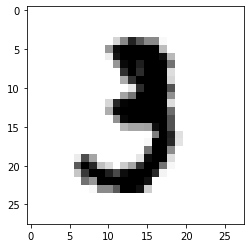

In [ ]:
from keras.datasets import mnist
import matplotlib.pyplot as plt
%matplotlib inline  

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
digit = train_images[10] # Select an arbitrary case for our example

# Checking the shape of our tensor (in this case, the image)
print('Raw Tensor shape:', train_images.shape)

# Now performing some slices of our image:
print('Tensor Slice [0:100] shape:', train_images[:100].shape)

# Equivalently
print('Tensor Slice [0:100] shape:', train_images[:100, :, :].shape)

# Or verbosely:
print('Tensor Slice [0:100] shape:', train_images[:100, :28, :28].shape)

# Display an example image for context
plt.imshow(digit, cmap=plt.cm.binary) 
plt.show()

In the above example, we sliced our tensor to obtain 100 of the 60,000 images. You can also slice tensors along other axes. For example, the first dimension is which image we are referring to, while the second and third axes are the pixels of these images themselves. For example, we could limit the images to the bottom right hand quadrant like this:

Sliced tensor shape (includes all images but only the lower right hand corner of each: (60000, 14, 14)


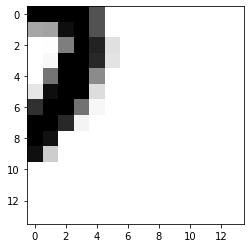

In [ ]:
lower_right_quadrant = train_images[:,14:,14:]
print('Sliced tensor shape (includes all images but only the lower right hand corner of each:',
      lower_right_quadrant.shape)
plt.imshow(lower_right_quadrant[10], cmap=plt.cm.binary) # Display the 10th image from our sliced tensor
plt.show()

### Tensor Operations
    * Element-wise
    * Broadcasting
    * Tensor dot
    
These are the three main operations that you will see in future implementations. Element-wise addition (or other operations) simply updates each element with the corresponding element from another tensor. For example, here is the result of an element-wise addition of two NumPy arrays:

In [ ]:
import numpy as np
np.array([1, 2, 3, 4]) + np.array([5, 6, 7, 8])

array([ 6,  8, 10, 12])

Broadcasting operations can be used when tensors are of different dimensions. For example, we could add the vector `[1, 2, 3]` to a 3 by 4 matrix like this:

In [ ]:
A = np.array(range(12)).reshape(4,3)
print('A:\n', A, '\n')

B = np.array([1, 2, 3]) #.reshape(1, -1)
print('B:', B, '\n')

A += B # Update with broadcasting
print('Updated A:\n', A)

A:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]] 

B: [1 2 3] 

Updated A:
 [[ 1  3  5]
 [ 4  6  8]
 [ 7  9 11]
 [10 12 14]]


Noticed how B was broadcasted across A; a copy of B was added to each row in A.
Finally, as with our previous work with linear algebra, we will also commonly take the dot product of tensors.
Recall that this is the sum of the element-wise products. Let's start with a very simple example:

In [ ]:
# Recall that B is the vector [1, 2, 3]
# Taking the dot product of B and itself is equivalent to
# 1*1 + 2*2 + 3*3 = 1 + 4 + 9 = 14
print(np.dot(B,B))

14


Examining a slightly more complex example:

In [ ]:
A = np.array(range(12)).reshape(4, 3)
print('A:\n', A, '\n')

B = np.array([1,2,3]) #.reshape(1, -1)
print('B:', B, '\n')

np.dot(A, B)

A:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]] 

B: [1 2 3] 



array([ 8, 26, 44, 62])

Here the first element is the sum of the first row of $A$ multiplied by $B$ elementwise:  
$$ 0*1 + 1*2 + 2*3 = 0 + 2 + 6 = 8 $$ 

Followed by the sum of the second row of $A$ multiplied by $B$ elementwise:  

$$ 3*1 + 4*2 + 5*3 = 3 + 8 + 15 = 26 $$

and so on.

## Build a Neural Network with Keras

### Importing the packages

As usual, we need to import some classes...

In [ ]:
from keras import models
from keras import layers
from keras import optimizers

### Decide on the network architecture

Afterwards, we define the type of network. We will discuss other network types later, but to date, we have examined sequential models; one layer builds upon the previous one and continues to chain until the end.

```python
model = models.Sequential()
```

### Add layers

Once we have initialized a network object as shown above, we can then add layers to the network which includes the number of layers we wish to add, as well as which activation function we want to use. For example, when coding from scratch, we previously used the sigmoid and ReLu activation functions.   

The `Dense()` class indicates that this layer will be fully connected. There are other layer architectures that we will discuss further in upcoming labs and lessons.

Finally, the `input_shape` parameter is often optional. That is, in successive layers, Keras implies the required shape of the layer to be added based on the shape of the previous layer.

```python
model.add(layers.Dense(units, activation, input_shape))
```

### Compile the model

Once we have defined the network architecture and added layers to that network, we then compile the model before then training that model on our data.

```python
model.compile(optimizer=optimizers.RMSprop(lr=0.001),
              loss='mse',
              metrics=['accuracy'])
```

Notice that this is also where we specify our loss function.

### Train the model

```python
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))
```

Why batches? If you push all your samples through at once, you have to wait until everything is processed and can only start backpropagating then. Therefore, batches are used, so that after each batch has done a forward propagation step, backward propagation can happen again. In essence, it's "mini-batch" gradient descent.


Here's some further notes regarding these terms from the Keras documentation FAQ:


* **Sample**: one element of a dataset.  
    * *Example*: one image is a sample in a convolutional network  
    * *Example*: one audio file is a sample for a speech recognition model  
    
* **Batch**: a set of $N$ samples. The samples in a batch are processed independently, in parallel. If training, a batch results in only one update to the model.  
* A batch generally approximates the distribution of the input data better than a single input. The larger the batch, the better the approximation; however, it is also true that the batch will take longer to process and will still result in only one update. For inference (evaluate/predict), it is recommended to pick a batch size that is as large as you can afford without going out of memory (since larger batches will usually result in faster evaluation/prediction).
* **Epoch**: an arbitrary cutoff, generally defined as "one pass over the entire dataset", used to separate training into distinct phases, which is useful for logging and periodic evaluation.
* When using `validation_data` or `validation_split` with the `.fit()` method of Keras models, evaluation will be run at the end of every epoch.
* Within Keras, there is the ability to add callbacks specifically designed to be run at the end of an epoch. Examples of these are learning rate changes and model checkpointing (saving).

### Plot

When we fit the model as shown above, we not only update the model object itself, we are also returned a history associated with the model. (Hence our variable name.) With this, we can retrieve further information regarding how the model training progressed from epoch to epoch. To do this, you can access the `.history` attribute of the returned object. Given our variable naming above, we would thus have:

`history.history`

This will return a dictionary of the metrics we indicated when compiling the model. By default, the loss criteria will always be included as well. So in our example, this dictionary will have two keys, one for the loss, and one for the accuracy. If you wish to plot learning curves for the loss or accuracy versus the epochs, you can then simply retrieve these lists. For example:

`history.history['loss']`

would return a list of the loss at each epoch.

## Make Predictions

As with scikit-learn and other packages, making predictions from a trained model is relatively straightforward. To do this, you can simply use the `.predict()` method built into the model object. For example:   

```python
y_hat = model.predict(x)
```

## Evaluate the Model

Similarly, we can use the `.evaluate()` method in order to compute the loss and other specified metrics for our trained model.

For example,   

```python
model.evaluate(X_train, X_train_labels)
``` 

will return the final loss associated with the model for the training data as well as any other metrics that were specified during compilation.

Similarly, 

```python
model.evaluate(X_test, X_test_labels)
``` 
will return the final loss associated with the model for the test data as well as any other specified metrics.

---

## Required Packages

We'll start by importing all of the required packages and classes.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical
from sklearn import preprocessing
from keras.preprocessing.text import Tokenizer
from keras import models
from keras import layers
from keras import optimizers

Using TensorFlow backend.


## Load the data

In this lab you will be classifying bank complaints available in the `'data/introduction_to_keras_lab/Bank_complaints.csv'` file.

In [ ]:
# Import data
df = None

# Inspect data
print(df.info())
df.head()

As mentioned earlier, your task is to categorize banking complaints into various predefined categories. Preview what these categories are and what percent of the complaints each accounts for.

In [ ]:
# Your code here

## Preprocessing

Before we build our neural network, we need to do several preprocessing steps. First, we will create word vector counts (a bag of words type representation) of our complaints text. Next, we will change the category labels to integers. Finally, we will perform our usual train-test split before building and training our neural network using Keras. With that, let's start munging our data! 

## One-hot encoding of the complaints

Our first step again is to transform our textual data into a numerical representation. As we saw in some of our previous lessons on NLP, there are many ways to do this. Here, we'll use the `Tokenizer()` class from the `preprocessing.text` sub-module of the Keras package.   

As with our previous work using NLTK, this will transform our text complaints into word vectors. (Note that the method of creating a vector is different from our previous work with NLTK; as you'll see, word order will be preserved as opposed to a bag of words representation). In the below code, we'll only keep the 2,000 most common words and use one-hot encoding.

In [ ]:
# As a quick preliminary, briefly review the docstring for keras.preprocessing.text.Tokenizer
Tokenizer?

In [ ]:
# ⏰ This cell may take about thirty seconds to run

# Raw text complaints
complaints = df['Consumer complaint narrative'] 

# Initialize a tokenizer 
tokenizer = Tokenizer(num_words=2000) 

# Fit it to the complaints
tokenizer.fit_on_texts(complaints) 

# Generate sequences
sequences = tokenizer.texts_to_sequences(complaints) 
print('sequences type:', type(sequences))

# Similar to sequences, but returns a numpy array
one_hot_results= tokenizer.texts_to_matrix(complaints, mode='binary') 
print('one_hot_results type:', type(one_hot_results))

# Useful if we wish to decode (more explanation below)
word_index = tokenizer.word_index 

# Tokens are the number of unique words across the corpus
print('Found %s unique tokens.' % len(word_index)) 

# Our coded data
print('Dimensions of our coded results:', np.shape(one_hot_results)) 

sequences type: <class 'list'>
one_hot_results type: <class 'numpy.ndarray'>
Found 50110 unique tokens.
Dimensions of our coded results: (60000, 2000)


## Decoding Word Vectors 

As a note, you can also decode these vectorized representations of the reviews. The `word_index` variable, defined above, stores the mapping from the label number to the actual word. Somewhat tediously, we can turn this dictionary inside out and map it back to our word vectors, giving us roughly the original complaint back. (As you'll see, the text won't be identical as we limited ourselves to top 2000 words.)

## Python Review / Mini Challenge

While a bit tangential to our main topic of interest, we need to reverse our current dictionary `word_index` which maps words from our corpus to integers. In decoding our `one_hot_results`, we will need to create a dictionary of these integers to the original words. Below, take the `word_index` dictionary object and change the orientation so that the values are keys and the keys values. In other words, you are transforming something of the form {A:1, B:2, C:3} to {1:A, 2:B, 3:C}.

In [ ]:
# Your code here
reverse_index = None

## Back to Decoding Our Word Vectors...

In [ ]:
comment_idx_to_preview = 19
print('Original complaint text:')
print(complaints[comment_idx_to_preview])
print('\n\n')

# The reverse_index cell block above must be complete in order for this cell block to successively execute 
decoded_review = ' '.join([reverse_index.get(i) for i in sequences[comment_idx_to_preview]])
print('Decoded review from Tokenizer:')
print(decoded_review)

Original complaint text:
I have already filed several complaints about AES/PHEAA. I was notified by a XXXX XXXX let @ XXXX, who pretended to be from your office, he said he was from CFPB. I found out this morning he is n't from your office, but is actually works at XXXX. 

This has wasted weeks of my time. They AES/PHEAA confirmed and admitted ( see attached transcript of XXXX, conversation at XXXX ( XXXX ) with XXXX that proves they verified the loans are not mine ) the student loans they had XXXX, and collected on, and reported negate credit reporting in my name are in fact, not mine. 
They conclued their investigation on XXXX admitting they made a mistake and have my name on soneone elses loans. I these XXXX loans total {$10000.00}, original amount. My XXXX loans I got was total {$3500.00}. We proved by providing AES/PHEAA, this with my original promissary notes I located recently, the XXXX of my college provided AES/PHEAA with their original shoeinf amounts of my XXXX loans which s

## Convert the Products to Numerical Categories

On to step two of our preprocessing: converting our descriptive categories into integers.

In [ ]:
product = df['Product']

# Initialize
le = preprocessing.LabelEncoder() 
le.fit(product)
print('Original class labels:')
print(list(le.classes_))
print('\n')
product_cat = le.transform(product)  

# If you wish to retrieve the original descriptive labels post production
# list(le.inverse_transform([0, 1, 3, 3, 0, 6, 4])) 

print('New product labels:')
print(product_cat)
print('\n')

# Each row will be all zeros except for the category for that observation 
print('One hot labels; 7 binary columns, one for each of the categories.') 
product_onehot = to_categorical(product_cat)
print(product_onehot)
print('\n')

print('One hot labels shape:')
print(np.shape(product_onehot))

Original class labels:
['Bank account or service', 'Checking or savings account', 'Consumer Loan', 'Credit card', 'Credit reporting', 'Mortgage', 'Student loan']


New product labels:
[6 6 6 ... 4 4 4]


One hot labels; 7 binary columns, one for each of the categories.
[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


One hot labels shape:
(60000, 7)


## Train-test split

Now for our final preprocessing step: the usual train-test split.

In [ ]:
random.seed(123)
test_index = random.sample(range(1,10000), 1500)

test = one_hot_results[test_index]
train = np.delete(one_hot_results, test_index, 0)

label_test = product_onehot[test_index]
label_train = np.delete(product_onehot, test_index, 0)

print('Test label shape:', np.shape(label_test))
print('Train label shape:', np.shape(label_train))
print('Test shape:', np.shape(test))
print('Train shape:', np.shape(train))

Test label shape: (1500, 7)
Train label shape: (58500, 7)
Test shape: (1500, 2000)
Train shape: (58500, 2000)


## Building the network

Let's build a fully connected (Dense) layer network with relu activation in Keras. You can do this using: `Dense(16, activation='relu')`. 

In this example, use two hidden layers with 50 units in the first layer and 25 in the second, both with a `'relu'` activation function. Because we are dealing with a multiclass problem (classifying the complaints into 7 categories), we use a use a `'softmax'` classifier in order to output 7 class probabilities per case.

In [ ]:
# Initialize a sequential model
model = None

# Two layers with relu activation



# One layer with softmax activation 


## Compiling the model

Now, compile the model! This time, use `'categorical_crossentropy'` as the loss function and stochastic gradient descent, `'SGD'` as the optimizer. As in the previous lesson, include the accuracy as a metric.

In [ ]:
# Compile the model


## Training the model

In the compiler, you'll be passing the optimizer (SGD = stochastic gradient descent), loss function, and metrics. Train the model for 120 epochs in mini-batches of 256 samples.

_Note:_ ⏰ _Your code may take about one to two minutes to run._

In [ ]:
# Train the model 
history = None

Recall that the dictionary `history` has two entries: the loss and the accuracy achieved using the training set.

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'acc'])

## Plot the results

As you might expect, we'll use our `matplotlib` for graphing. Use the data stored in the `history_dict` above to plot the loss vs epochs and the accuracy vs epochs.

In [ ]:
# Plot the loss vs the number of epoch

In [ ]:
# Plot the training accuracy vs the number of epochs


It seems like we could just keep on going and accuracy would go up!

## Make predictions

Finally, it's time to make predictions. Use the relevant method discussed in the previous lesson to output (probability) predictions for the test set.

In [ ]:
# Output (probability) predictions for the test set 
y_hat_test = None

## Evaluate Performance

Finally, print the loss and accuracy for both the train and test sets of the final trained model.

In [ ]:
# Print the loss and accuracy for the training set 
results_train = None
results_train

In [ ]:
# Print the loss and accuracy for the test set 
results_test = None
results_test